In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Limpeza e Pré-processamento de Dados

Tratamento de nulos, duplicidades e inconsistências

Transformação e padronização das variáveis

Análise de Valores Únicos para Colunas Categóricas

Codificação de variáveis categóricas
Seleção e criação de variáveis
Separação entre treino e teste

In [ ]:
df_application = pd.read_csv('application_record.csv')
df_credit = pd.read_csv('credit_record.csv')

In [ ]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [ ]:
df_credit.head()


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [ ]:
print('Valores ausentes em df_application:')
display(df_application.isnull().sum())

print('\nValores ausentes em df_credit:')
display(df_credit.isnull().sum())

Valores ausentes em df_application:


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0



Valores ausentes em df_credit:


,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [ ]:
#Análise de Valores Únicos para Colunas Categóricas em df_application

categorical_cols = df_application.select_dtypes(include='object').columns #Selecione as colunas que contêm dados do tipo texto.

for col in categorical_cols: # for = estrutura de repetição - para cada item dessa lista (coluna), faça alguma coisa
    print(f'\n{col}:') # f = string = permite colocar uma variável dentro do texto; o \n = quebra de linha
    display(df_application[col].value_counts())


CODE_GENDER:


,count
CODE_GENDER,
F,294440
M,144117



FLAG_OWN_CAR:


,count
FLAG_OWN_CAR,
N,275459
Y,163098



FLAG_OWN_REALTY:


...

,count
NAME_FAMILY_STATUS,
Married,299828
Single / not married,55271
Civil marriage,36532
Separated,27251
Widow,19675



NAME_HOUSING_TYPE:


,count
NAME_HOUSING_TYPE,
House / apartment,393831
With parents,19077
Municipal apartment,14214
Rented apartment,5974
Office apartment,3922
Co-op apartment,1539



OCCUPATION_TYPE:


,count
OCCUPATION_TYPE,
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520
Cooking staff,8076


In [ ]:
display(df_application.describe())

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [ ]:
print(f'Duplicatas de ID em df_application: {df_application.duplicated(subset=["ID"]).sum()}')
print(f'Duplicatas de ID em df_credit: {df_credit.duplicated(subset=["ID"]).sum()}')

Duplicatas de ID em df_application: 47
Duplicatas de ID em df_credit: 1002590


In [ ]:
print(f'Shape de df_application: {df_application.shape}')
print(f'Shape de df_credit: {df_credit.shape}')

Shape de df_application: (438557, 18)
Shape de df_credit: (1048575, 3)


Tratamento das informações ausentes de OCCUPATION_TYPE como 'Unknown'


In [ ]:
df_application_cleaned = df_application.copy()

# Impute 'OCCUPATION_TYPE' with 'Unknown'
df_application_cleaned['OCCUPATION_TYPE'] = df_application_cleaned['OCCUPATION_TYPE'].fillna('Unknown')

# Impute other specified columns with their mode
columns_to_impute_mode = [
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_MOBIL',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'CNT_FAM_MEMBERS'
]

for col in columns_to_impute_mode:
    mode_value = df_application_cleaned[col].mode()[0] # Encontra a moda da coluna e guarda o primeiro valor [0] encontrado na variável
    df_application_cleaned[col] = df_application_cleaned[col].fillna(mode_value)

# Ele pega algumas colunas que possuem valores vazios (NaN) e preenche esses vazios com o valor que mais aparece naquela coluna - esse valor que mais aparece é chamado de moda (mode).

# Verify that there are no remaining missing values from this step
print('Valores ausentes em df_application_cleaned após a imputação de categóricas/flags:')
display(df_application_cleaned.isnull().sum())

Valores ausentes em df_application_cleaned após a imputação de categóricas/flags:


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


As colunas `DAYS_BIRTH` e `DAYS_EMPLOYED` contêm valores em dias e são frequentemente negativos, indicando a contagem de dias retroativamente. Além disso, `DAYS_EMPLOYED` pode conter um valor especial (`365243`) que representa 'desempregado'.

Para facilitar a interpretação e a modelagem, converteremos esses valores para anos e trataremos o valor especial de `DAYS_EMPLOYED` de forma explícita, criando uma nova coluna para indicar se a pessoa está desempregada.

In [ ]:
# Tratamento das colunas days_birth e days_employed

if 'DAYS_BIRTH' in df_application_cleaned.columns and 'DAYS_EMPLOYED' in df_application_cleaned.columns:
    # Converter DAYS_BIRTH para anos e torná-lo positivo
    df_application_cleaned['AGE_YEARS'] = abs(df_application_cleaned['DAYS_BIRTH'] / 365.25)

    # Tratar DAYS_EMPLOYED:
    # O valor 365243 geralmente indica 'desempregado'. Vamos criar uma flag para isso.
    df_application_cleaned['IS_EMPLOYED'] = df_application_cleaned['DAYS_EMPLOYED'].apply(lambda x: 0 if x == 365243 else 1)

    # Converter DAYS_EMPLOYED para anos para quem está empregado (e torná-lo positivo)
    # Para os desempregados (365243), vamos definir como 0 ou NaN, dependendo da abordagem.
    # Optamos por 0 aqui para quem não está empregado.
    df_application_cleaned['EMPLOYMENT_YEARS'] = df_application_cleaned['DAYS_EMPLOYED'].apply(lambda x: abs(x / 365.25) if x != 365243 else 0)

    # Remover as colunas originais DAYS_BIRTH e DAYS_EMPLOYED
    df_application_cleaned.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True) #inplace true - altera no próprio DataFrame
else:
    print("Warning: 'DAYS_BIRTH' and/or 'DAYS_EMPLOYED' columns were not found. Assuming they were already processed in a previous run.")

# Verificar a distribuição dos novos atributos e valores ausentes restantes
print('Novas colunas e valores ausentes após tratamento de datas:')
print('AGE_YEARS (Média):', df_application_cleaned['AGE_YEARS'].mean())
print('EMPLOYMENT_YEARS (Média para empregados):', df_application_cleaned[df_application_cleaned['IS_EMPLOYED'] == 1]['EMPLOYMENT_YEARS'].mean())
print('IS_EMPLOYED (Contagem):\n', df_application_cleaned['IS_EMPLOYED'].value_counts())

display(df_application_cleaned.isnull().sum())

Novas colunas e valores ausentes após tratamento de datas:
AGE_YEARS (Média): 43.7998758347832
EMPLOYMENT_YEARS (Média para empregados): 7.181526898512643
IS_EMPLOYED (Contagem):
 IS_EMPLOYED
1    363228
0     75329
Name: count, dtype: int64


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [ ]:
display(df_credit['STATUS'].value_counts()) # Contar os valores únicos da coluna STATUS

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


Tratamento da base de dados df_credit

In [ ]:
display(df_credit['MONTHS_BALANCE'].describe())

,MONTHS_BALANCE
count,1.048575e+06
mean,-1.913700e+01
std,1.402350e+01
min,-6.000000e+01
25%,-2.900000e+01
50%,-1.700000e+01
75%,-7.000000e+00
max,0.000000e+00


quer dizer que o mínimo vai até 60 meses atrás




In [ ]:
print(df_credit.groupby('ID')['STATUS'].nunique().describe())

count    45985.000000
mean         2.047255
std          0.784970
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          8.000000
Name: STATUS, dtype: float64


Existem 45.985 clientes e, em média, cada cliente possui aproximadamente 2 tipos diferentes de STATUS ao longo do histórico.

In [ ]:
display(df_credit.groupby('ID')['STATUS'].value_counts().head(20))

ID       STATUS
5001711  0          3
         X          1
5001712  0         10
         C          9
5001713  X         22
5001714  X         15
5001715  X         60
5001717  0         17
         C          5
5001718  0         24
         X         10
         C          3
         1          2
5001719  C         41
         0          2
5001720  0         29
         1          7
5001723  X         23
         0          8
5001724  C         22
Name: count, dtype: int64

In [ ]:
df_credit_bad = df_credit[df_credit['STATUS'].isin(['1', '2', '3', '4', '5'])]

numero_clientes_bad = df_credit_bad['ID'].nunique()

print('Número de clientes com pelo menos um atraso de 30 dias:', numero_clientes_bad)

Número de clientes com pelo menos um atraso de 30 dias: 5350


In [ ]:
percentual_bad = numero_clientes_bad / df_credit['ID'].nunique() * 100

print('Percentual de clientes com pelo menos um atraso de 30 dias:',
      percentual_bad)

Percentual de clientes com pelo menos um atraso de 30 dias: 11.634228552788953


In [ ]:
df_credit['BAD_CREDIT'] = df_credit['STATUS'].isin(['1', '2', '3', '4', '5']) #O valor de STATUS está dentro desta lista: ['1', '2', '3', '4', '5']?

display(df_credit[['STATUS', 'BAD_CREDIT']].head(20))

,STATUS,BAD_CREDIT
0,X,False
1,0,False
2,0,False
3,0,False
4,C,False
5,C,False
6,C,False
7,C,False
8,C,False
9,C,False


In [ ]:
display(df_credit['BAD_CREDIT'].value_counts()) # mostrar quantos registros (meses), e não quantos clientes, foram classificados como atraso relevante

,count
BAD_CREDIT,
False,1034381
True,14194


In [ ]:
target_by_id = df_credit.groupby('ID')['BAD_CREDIT'].max()

display(target_by_id.head(10))

,BAD_CREDIT
ID,
5001711,False
5001712,False
5001713,False
5001714,False
5001715,False
5001717,False
5001718,True
5001719,False
5001720,True


In [ ]:
target_by_id = target_by_id.reset_index() #tira o ID do índice e transforma novamente em uma coluna

display(target_by_id.head(10))

,ID,BAD_CREDIT
0,5001711,False
1,5001712,False
2,5001713,False
3,5001714,False
4,5001715,False
5,5001717,False
6,5001718,True
7,5001719,False
8,5001720,True
9,5001723,False


In [ ]:
df_model = df_application_cleaned.merge(
    target_by_id,
    on='ID',
    how='inner'
)

display(df_model.head())

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,IS_EMPLOYED,EMPLOYMENT_YEARS,BAD_CREDIT
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,32.867899,1,12.435318,True
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,32.867899,1,12.435318,True
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58.792608,1,3.104723,False
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52.320329,1,8.353183,False
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52.320329,1,8.353183,False


In [ ]:
print('Linhas:', len(df_model))
print('Colunas:', len(df_model.columns))

Linhas: 36457
Colunas: 20


In [ ]:
display(df_model['BAD_CREDIT'].value_counts())

,count
BAD_CREDIT,
False,32166
True,4291


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  FLAG_MOBIL           36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  OCCUPATION_TYPE      36457 non-null  object 
 15  CNT_FAM_MEMBERS      36457 non-null 

One-Hot Encoding transforma uma variável categórica em várias colunas 0/1, sem criar uma ordem artificial entre as categorias.

In [ ]:
# passar por cada coluna da nossa lista e mostrar quais categorias aparecem e quantas pessoas estão em cada uma.

colunas_categoricas = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

for col in colunas_categoricas:
    print('\n', col)
    print(df_model[col].value_counts())


 CODE_GENDER
CODE_GENDER
F    24430
M    12027
Name: count, dtype: int64

 FLAG_OWN_CAR
FLAG_OWN_CAR
N    22614
Y    13843
Name: count, dtype: int64

 FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    24506
N    11951
Name: count, dtype: int64

 NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64

 NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64

 NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 25048
Single / not married     4829
Civil marriage           2945
Separated                2103
Widow                    1532
Name: count, dtype: int64

 NAME_HOUSING_TYPE
NAME_HOUSING_TYPE
House / apartment      32548
With paren

In [ ]:
# Tratamento das variáveis categóricas

df_model['CODE_GENDER'] = df_model['CODE_GENDER'].map({'F': 0, 'M': 1})

df_model['FLAG_OWN_CAR'] = df_model['FLAG_OWN_CAR'].map({'N': 0, 'Y': 1})

df_model['FLAG_OWN_REALTY'] = df_model['FLAG_OWN_REALTY'].map({'N': 0, 'Y': 1})

df_model[['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']].head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY
0,1,1,1
1,1,1,1
2,1,1,1
3,0,0,1
4,0,0,1


CODE_GENDER:
F → 0
M → 1

FLAG_OWN_CAR:
N → 0
Y → 1

FLAG_OWN_REALTY:
N → 0
Y → 1

In [ ]:
pd.get_dummies(df_model['NAME_INCOME_TYPE'])

,Commercial associate,Pensioner,State servant,Student,Working
0,False,False,False,False,True
1,False,False,False,False,True
2,False,False,False,False,True
3,True,False,False,False,False
4,True,False,False,False,False
...,...,...,...,...,...
36452,False,False,False,False,True
36453,True,False,False,False,False
36454,False,True,False,False,False
36455,False,False,False,False,True


In [ ]:
income_dummies = pd.get_dummies(df_model['NAME_INCOME_TYPE'])

df_model = pd.concat([df_model, income_dummies], axis=1)

df_model = df_model.drop(columns=['NAME_INCOME_TYPE'])

In [ ]:
df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,...,CNT_FAM_MEMBERS,AGE_YEARS,IS_EMPLOYED,EMPLOYMENT_YEARS,BAD_CREDIT,Commercial associate,Pensioner,State servant,Student,Working
0,5008804,1,1,1,0,427500.0,Higher education,Civil marriage,Rented apartment,1,...,2.0,32.867899,1,12.435318,True,False,False,False,False,True
1,5008805,1,1,1,0,427500.0,Higher education,Civil marriage,Rented apartment,1,...,2.0,32.867899,1,12.435318,True,False,False,False,False,True
2,5008806,1,1,1,0,112500.0,Secondary / secondary special,Married,House / apartment,1,...,2.0,58.792608,1,3.104723,False,False,False,False,False,True
3,5008808,0,0,1,0,270000.0,Secondary / secondary special,Single / not married,House / apartment,1,...,1.0,52.320329,1,8.353183,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,Secondary / secondary special,Single / not married,House / apartment,1,...,1.0,52.320329,1,8.353183,False,True,False,False,False,False


In [ ]:
education_dummies = pd.get_dummies(df_model['NAME_EDUCATION_TYPE'])

print(education_dummies.head())

   Academic degree  Higher education  Incomplete higher  Lower secondary  \
0            False              True              False            False   
1            False              True              False            False   
2            False             False              False            False   
3            False             False              False            False   
4            False             False              False            False   

   Secondary / secondary special  
0                          False  
1                          False  
2                           True  
3                           True  
4                           True  


In [ ]:
df_model = pd.concat([df_model, education_dummies], axis=1)
df_model = df_model.drop(columns=['NAME_EDUCATION_TYPE'])

df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,...,Commercial associate,Pensioner,State servant,Student,Working,Academic degree,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special
0,5008804,1,1,1,0,427500.0,Civil marriage,Rented apartment,1,1,...,False,False,False,False,True,False,True,False,False,False
1,5008805,1,1,1,0,427500.0,Civil marriage,Rented apartment,1,1,...,False,False,False,False,True,False,True,False,False,False
2,5008806,1,1,1,0,112500.0,Married,House / apartment,1,0,...,False,False,False,False,True,False,False,False,False,True
3,5008808,0,0,1,0,270000.0,Single / not married,House / apartment,1,0,...,True,False,False,False,False,False,False,False,False,True
4,5008809,0,0,1,0,270000.0,Single / not married,House / apartment,1,0,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
family_dummies = pd.get_dummies(df_model['NAME_FAMILY_STATUS'])

print(family_dummies.head())

   Civil marriage  Married  Separated  Single / not married  Widow
0            True    False      False                 False  False
1            True    False      False                 False  False
2           False     True      False                 False  False
3           False    False      False                  True  False
4           False    False      False                  True  False


In [ ]:
df_model = pd.concat([df_model, family_dummies], axis=1)
df_model = df_model.drop(columns=['NAME_FAMILY_STATUS'])

df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,...,Academic degree,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Civil marriage,Married,Separated,Single / not married,Widow
0,5008804,1,1,1,0,427500.0,Rented apartment,1,1,0,...,False,True,False,False,False,True,False,False,False,False
1,5008805,1,1,1,0,427500.0,Rented apartment,1,1,0,...,False,True,False,False,False,True,False,False,False,False
2,5008806,1,1,1,0,112500.0,House / apartment,1,0,0,...,False,False,False,False,True,False,True,False,False,False
3,5008808,0,0,1,0,270000.0,House / apartment,1,0,1,...,False,False,False,False,True,False,False,False,True,False
4,5008809,0,0,1,0,270000.0,House / apartment,1,0,1,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
housing_dummies = pd.get_dummies(df_model['NAME_HOUSING_TYPE'])

print(housing_dummies.head())

   Co-op apartment  House / apartment  Municipal apartment  Office apartment  \
0            False              False                False             False   
1            False              False                False             False   
2            False               True                False             False   
3            False               True                False             False   
4            False               True                False             False   

   Rented apartment  With parents  
0              True         False  
1              True         False  
2             False         False  
3             False         False  
4             False         False  


In [ ]:
df_model = pd.concat([df_model, housing_dummies], axis=1)
df_model = df_model.drop(columns=['NAME_HOUSING_TYPE'])

df_model.head()



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,Married,Separated,Single / not married,Widow,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
0,5008804,1,1,1,0,427500.0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
1,5008805,1,1,1,0,427500.0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
2,5008806,1,1,1,0,112500.0,1,0,0,0,...,True,False,False,False,False,True,False,False,False,False
3,5008808,0,0,1,0,270000.0,1,0,1,1,...,False,False,True,False,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,1,0,1,1,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
occupation_dummies = pd.get_dummies(df_model['OCCUPATION_TYPE'])

print(occupation_dummies.head())

   Accountants  Cleaning staff  Cooking staff  Core staff  Drivers  HR staff  \
0        False           False          False       False    False     False   
1        False           False          False       False    False     False   
2        False           False          False       False    False     False   
3        False           False          False       False    False     False   
4        False           False          False       False    False     False   

   High skill tech staff  IT staff  Laborers  Low-skill Laborers  Managers  \
0                  False     False     False               False     False   
1                  False     False     False               False     False   
2                  False     False     False               False     False   
3                  False     False     False               False     False   
4                  False     False     False               False     False   

   Medicine staff  Private service staff  Realty a

In [ ]:
df_model = pd.concat([df_model, occupation_dummies], axis=1)
df_model = df_model.drop(columns=['OCCUPATION_TYPE'])

df_model.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,Low-skill Laborers,Managers,Medicine staff,Private service staff,Realty agents,Sales staff,Secretaries,Security staff,Unknown,Waiters/barmen staff
0,5008804,1,1,1,0,427500.0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
1,5008805,1,1,1,0,427500.0,1,1,0,0,...,False,False,False,False,False,False,False,False,True,False
2,5008806,1,1,1,0,112500.0,1,0,0,0,...,False,False,False,False,False,False,False,True,False,False
3,5008808,0,0,1,0,270000.0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,False
4,5008809,0,0,1,0,270000.0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             36457 non-null  int64  
 1   CODE_GENDER                    36457 non-null  int64  
 2   FLAG_OWN_CAR                   36457 non-null  int64  
 3   FLAG_OWN_REALTY                36457 non-null  int64  
 4   CNT_CHILDREN                   36457 non-null  int64  
 5   AMT_INCOME_TOTAL               36457 non-null  float64
 6   FLAG_MOBIL                     36457 non-null  int64  
 7   FLAG_WORK_PHONE                36457 non-null  int64  
 8   FLAG_PHONE                     36457 non-null  int64  
 9   FLAG_EMAIL                     36457 non-null  int64  
 10  CNT_FAM_MEMBERS                36457 non-null  float64
 11  AGE_YEARS                      36457 non-null  float64
 12  IS_EMPLOYED                    36457 non-null 

In [ ]:
# Verificando as novas features e atualizando as colunas do X para incluir as novas features.

X = df_model.drop(columns=['ID', 'BAD_CREDIT'], errors='ignore')
y = df_model['BAD_CREDIT']

display(X.head())

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,...,Low-skill Laborers,Managers,Medicine staff,Private service staff,Realty agents,Sales staff,Secretaries,Security staff,Unknown,Waiters/barmen staff
0,1,1,1,0,427500.0,1,1,0,0,2.0,...,False,False,False,False,False,False,False,False,True,False
1,1,1,1,0,427500.0,1,1,0,0,2.0,...,False,False,False,False,False,False,False,False,True,False
2,1,1,1,0,112500.0,1,0,0,0,2.0,...,False,False,False,False,False,False,False,True,False,False
3,0,0,1,0,270000.0,1,0,1,1,1.0,...,False,False,False,False,False,True,False,False,False,False
4,0,0,1,0,270000.0,1,0,1,1,1.0,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df_model.columns[:15]

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'IS_EMPLOYED',
       'EMPLOYMENT_YEARS', 'BAD_CREDIT'],
      dtype='object')

In [ ]:
X = df_model.drop(columns=['ID', 'BAD_CREDIT'])
y = df_model['BAD_CREDIT']

In [ ]:
X.dtypes.value_counts()

,count
bool,40
int64,9
float64,4


In [ ]:
X.select_dtypes(include=['int64', 'float64']).columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'IS_EMPLOYED',
       'EMPLOYMENT_YEARS'],
      dtype='object')

In [ ]:
y.value_counts()

,count
BAD_CREDIT,
False,32166
True,4291


# Análise exploratória dos dados (?)

In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
CODE_GENDER,36457.0,0.329895,0.470181,0.000000,0.000000,0.000000,1.000000,1.000000e+00
FLAG_OWN_CAR,36457.0,0.379708,0.485321,0.000000,0.000000,0.000000,1.000000,1.000000e+00
FLAG_OWN_REALTY,36457.0,0.672189,0.469422,0.000000,0.000000,1.000000,1.000000,1.000000e+00
CNT_CHILDREN,36457.0,0.430315,0.742367,0.000000,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,36457.0,186685.736662,101789.226482,27000.000000,121500.000000,157500.000000,225000.000000,1.575000e+06
FLAG_MOBIL,36457.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
FLAG_WORK_PHONE,36457.0,0.225526,0.417934,0.000000,0.000000,0.000000,0.000000,1.000000e+00
FLAG_PHONE,36457.0,0.294813,0.455965,0.000000,0.000000,0.000000,1.000000,1.000000e+00
FLAG_EMAIL,36457.0,0.089722,0.285787,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CNT_FAM_MEMBERS,36457.0,2.198453,0.911686,1.000000,2.000000,2.000000,3.000000,2.000000e+01


<Axes: >

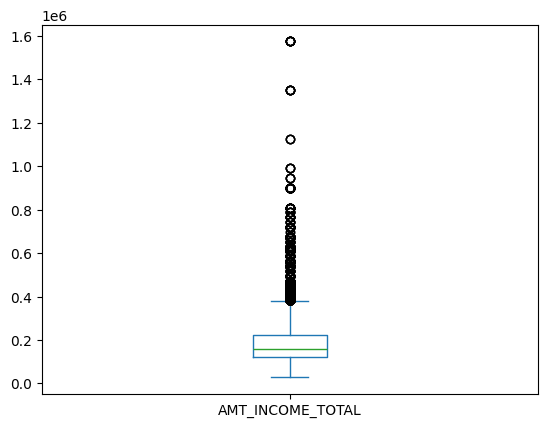

In [ ]:
X['AMT_INCOME_TOTAL'].plot(kind='box')

In [ ]:
X['CNT_CHILDREN'].value_counts().sort_index()

,count
CNT_CHILDREN,
0,25201
1,7492
2,3256
3,419
4,63
5,20
7,2
14,3
19,1


In [ ]:
X = X.drop(columns=['FLAG_MOBIL'])

In [ ]:
X.isnull().sum().sum()

np.int64(0)

# pré processamento dados

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Dividimos os dados em conjuntos de treinamento e teste.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nProporção de BAD_CREDIT no treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção de BAD_CREDIT no teste:")
print(y_test.value_counts(normalize=True))

Treino: (29165, 52)
Teste: (7292, 52)

Proporção de BAD_CREDIT no treino:
BAD_CREDIT
False    0.88229
True     0.11771
Name: proportion, dtype: float64

Proporção de BAD_CREDIT no teste:
BAD_CREDIT
False    0.882337
True     0.117663
Name: proportion, dtype: float64


📍 Onde estamos no projeto?

Agora terminamos a parte de:

Limpeza → preparação → separação treino/teste ✅

O próximo assunto é escala das variáveis.

E aqui tem uma ideia importante para entendermos antes de escrever código:

Imagine que o modelo recebe:

AGE_YEARS: algo entre 20 e 69
AMT_INCOME_TOTAL: algo entre 27.000 e 1.575.000
FLAG_EMAIL: 0 ou 1
uma dummy de profissão: 0 ou 1

Para alguns algoritmos, essas diferenças de escala podem atrapalhar. Por exemplo, no KNN, a distância entre duas pessoas é calculada usando as variáveis. Uma diferença de R$ 100.000 na renda poderia pesar enormemente mais do que uma diferença de idade de 5 anos.

Por isso:

Logistic Regression, KNN e SVM → precisam de atenção à escala.
Decision Tree e Random Forest → não precisam de escala.

In [ ]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

numeric_features

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'CNT_FAM_MEMBERS', 'AGE_YEARS', 'IS_EMPLOYED', 'EMPLOYMENT_YEARS'],
      dtype='object')

In [ ]:
scale_features = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'AGE_YEARS',
    'EMPLOYMENT_YEARS'
]

#Modelos

## Regressão Logística

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])



In [ ]:
X_train = X_train.drop(columns=['FAIXA_ETARIA', 'FAIXA_EMPREGABILIDADE', 'FAIXA_RENDA'], errors='ignore')
X_test = X_test.drop(columns=['FAIXA_ETARIA', 'FAIXA_EMPREGABILIDADE', 'FAIXA_RENDA'], errors='ignore')
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(random_state=42))])

In [ ]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test, y_pred_logistic)

array([[6434,    0],
       [ 855,    3]])

Então:

6434 → bons pagadores corretamente identificados

0 → bons pagadores classificados como maus

855 → maus pagadores classificados como bons ❗

3 → maus pagadores corretamente identificados

🚨 E aqui aparece o problema

Nosso modelo identificou apenas:

3 dos 858 maus pagadores do conjunto de teste.

Ou seja, ele está praticamente dizendo:

"Quase todo mundo é bom."

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1-score:", f1_score(y_test, y_pred_logistic))

Accuracy: 0.8827482172243555
Precision: 1.0
Recall: 0.0034965034965034965
F1-score: 0.006968641114982578


| Métrica       | Resultado | O que significa                                                 |
| ------------- | --------: | --------------------------------------------------------------- |
| **Accuracy**  |    88,27% | Acertou 88,27% das classificações                               |
| **Precision** |      100% | Quando disse "mau pagador", acertou                             |
| **Recall**    | **0,35%** | Encontrou só 0,35% dos maus pagadores                           |
| **F1-score**  | **0,70%** | Combinação de precision e recall, muito prejudicada pelo recall |


com balanceamento

In [ ]:
logistic_balanced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        class_weight='balanced'
    ))
])

In [ ]:
logistic_balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:
y_pred_logistic_balanced = logistic_balanced_pipeline.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred_logistic_balanced)

array([[3812, 2622],
       [ 443,  415]])

|               | Predito: bom | Predito: mau |
| ------------- | -----------: | -----------: |
| **Real: bom** |         3812 |         2622 |
| **Real: mau** |          443 |      **415** |

Compare com o modelo anterior:

|                               | Logistic normal | Logistic balanced |
| ----------------------------- | --------------: | ----------------: |
| Maus corretamente encontrados |           **3** |           **415** |
| Maus perdidos                 |             855 |           **443** |
| Bons classificados como maus  |               0 |              2622 |


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_balanced))
print("Precision:", precision_score(y_test, y_pred_logistic_balanced))
print("Recall:", recall_score(y_test, y_pred_logistic_balanced))
print("F1-score:", f1_score(y_test, y_pred_logistic_balanced))

Accuracy: 0.5796763576522216
Precision: 0.1366480079025354
Recall: 0.4836829836829837
F1-score: 0.21309370988446727


Resultado:

encontrou 415 dos 858 maus pagadores;

recall subiu de 0,35% → 48,37%;

mas classificou 2.622 bons pagadores como maus;

por isso a precision caiu para 13,66%.



Isso é chamado de trade-off entre precision e recall.


E é exatamente por isso que o F1-score é útil aqui: ele combina precision e recall em uma única métrica, sem ignorar completamente nenhuma das duas.

In [ ]:
resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Logistic Regression (balanced)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_logistic_balanced)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic_balanced)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic_balanced)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic_balanced)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.882748,1.000000,0.003497,0.006969
1,Logistic Regression (balanced),0.579676,0.136648,0.483683,0.213094


A Regressão Logística normal tem accuracy maior, mas praticamente não identifica BAD_CREDIT=True. A versão balanceada aumenta bastante o recall, mas gera muitos falsos positivos.

Isso já mostra por que, neste problema, accuracy isoladamente não é suficiente.

|                      | Accuracy | Precision | **Recall** |     F1 |
| -------------------- | -------: | --------: | ---------: | -----: |
| Regressão logística  |   88,27% |      100% |  **0,35%** |  0,70% |
| Logística `balanced` |   57,97% |    13,66% | **48,37%** | 21,31% |



O problema está principalmente no recall dos maus pagadores.

**A logística normal fez:**

**identificou 3 dos 858 maus pagadores;**

deixou passar 855;

acertou muitos bons pagadores, por isso a accuracy ficou alta.


Ou seja, ela praticamente aprendeu:

"Vou classificar quase todo mundo como bom pagador."


E como 88,2% da nossa base é de bons pagadores, isso dá uma accuracy aparentemente bonita — mas não atende bem à pergunta que queremos responder: quem tem perfil de mau pagador?


**Já a versão balanced tentou compensar o desequilíbrio:**

"Vou prestar mais atenção à classe minoritária."

**Aí encontrou 415 dos 858 maus pagadores, mas ao custo de classificar muitos bons pagadores como maus.**

Então, por enquanto, eu registraria assim no projeto:

**A regressão logística foi utilizada como modelo de referência. A versão convencional apresentou alta acurácia, porém baixa capacidade de identificar maus pagadores. A aplicação de class_weight='balanced' aumentou substancialmente o recall da classe minoritária, mas reduziu a precisão e a acurácia.**



##KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [ ]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [ ]:
y_pred_knn = knn_pipeline.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred_knn)

array([[6211,  223],
       [ 679,  179]])

|                   | Predito bom | Predito mau |
| ----------------- | ----------: | ----------: |
| **Realmente bom** |        6211 |         223 |
| **Realmente mau** |         679 |         179 |

ou

|             | **Previu BOM** | **Previu MAU** |
| ----------- | -------------: | -------------: |
| **Era BOM** |         6211 ✅ |         223 ⚠️ |
| **Era MAU** |          679 ❌ |          179 ✅ |



Então:

6211 → bons pagadores corretamente identificados (TN)

223 → bons pagadores classificados como maus (FP)

679 → maus pagadores classificados como bons (FN) ⚠️

179 → maus pagadores corretamente identificados (TP) ✅


O ponto mais interessante é esse:

Temos 858 maus pagadores no teste.

O KNN encontrou 179 deles:

179 / 858 ≈ 20,9% de recall.

Isso é bem melhor que a regressão logística normal, que encontrou só 3 (0,35%), mas ainda deixa passar aproximadamente 79% dos maus pagadores.

E ele também está cometendo alguns falsos positivos: 223 bons pagadores foram chamados de maus.

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.8763027975863961
Precision: 0.44527363184079605
Recall: 0.20862470862470864
F1-score: 0.2841269841269841


| Modelo             |   Accuracy |  Precision |     Recall |         F1 |
| ------------------ | ---------: | ---------: | ---------: | ---------: |
| Logística          |     88,27% |    100,00% |  **0,35%** |      0,70% |
| Logística balanced |     57,97% |     13,66% | **48,37%** |     21,31% |
| **KNN**            | **87,63%** | **44,53%** | **20,86%** | **28,41%** |


O que o KNN está dizendo?

Accuracy — 87,63%

Ele acertou aproximadamente 87,6% das classificações. Parece bom, mas lembra que 88,2% da nossa base já é de bons pagadores. Então não podemos olhar para esse número sozinho.

Precision — 44,53%

Quando o KNN diz:

"Essa pessoa é mau pagador."

ele está certo em aproximadamente 44,5% das vezes.

Ou seja, dos 402 casos que ele classificou como maus (223 + 179), 179 eram realmente maus.

**Recall — 20,86%**

Esse é especialmente importante para o nosso problema.

**Dos 858 maus pagadores reais, o KNN conseguiu identificar 179.**

Então ele encontrou cerca de 1 em cada 5 maus pagadores.

F1 — 28,41%

É uma métrica que combina precision e recall. Aqui ela ficou maior que a das duas versões da logística, mas ainda não temos como dizer que esse é o melhor resultado geral.

E tem uma coisa interessante

O KNN ficou com accuracy quase igual à logística normal:

87,63% vs. 88,27%

Mas a capacidade de encontrar maus pagadores aumentou bastante:

0,35% → 20,86% de recall

Então isso mostra exatamente por que accuracy sozinha seria enganosa nesse projeto.

##SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])

In [ ]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(random_state=42))])

In [ ]:
y_pred_svm = svm_pipeline.predict(X_test)

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[6426,    8],
       [ 848,   10]])

6426 → bons pagadores corretamente classificados como bons ✅

8 → bons classificados como maus ❌

848 → maus classificados como bons ❌ ← aqui está o grande problema

10 → maus corretamente identificados ✅


Temos 858 maus pagadores reais, e o SVM encontrou apenas 10.

O SVM padrão está sendo muito conservador para classificar alguém como mau pagador.

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.8826110806363138
Precision: 0.5555555555555556
Recall: 0.011655011655011656
F1-score: 0.0228310502283105


##Árvore de Decisão

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree_model = DecisionTreeClassifier(random_state=42)

In [ ]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_tree = tree_model.predict(X_test)
confusion_matrix(y_test, y_pred_tree)

array([[6157,  277],
       [ 590,  268]])

6157 → bons corretamente classificados como bons ✅

277 → bons classificados como maus ❌

590 → maus classificados como bons ❌

268 → maus corretamente identificados ✅


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

Accuracy: 0.8811025781678552
Precision: 0.4917431192660551
Recall: 0.3123543123543124
F1-score: 0.3820384889522452


Então ela está conseguindo um equilíbrio mais interessante entre:

encontrar maus pagadores (recall);
não acusar tantos bons pagadores indevidamente (precision).

Por isso o F1 da árvore ficou em 38,2%, maior que o F1 dos outros modelos que testamos até agora.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_forest = forest_model.predict(X_test)
confusion_matrix(y_test, y_pred_forest)

array([[6192,  242],
       [ 571,  287]])

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_forest))
print("Precision:", precision_score(y_test, y_pred_forest))
print("Recall:", recall_score(y_test, y_pred_forest))
print("F1-score:", f1_score(y_test, y_pred_forest))

Accuracy: 0.8885079539221065
Precision: 0.5425330812854442
Recall: 0.3344988344988345
F1-score: 0.4138428262436914


ROC-AUC

In [ ]:
y_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_logistic = roc_auc_score(y_test, y_proba_logistic)

print("ROC-AUC:", roc_auc_logistic)

ROC-AUC: 0.5501653692903304


In [ ]:
y_proba_logistic_balanced = logistic_balanced_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
roc_auc_logistic_balanced = roc_auc_score(
    y_test,
    y_proba_logistic_balanced
)

print("ROC-AUC:", roc_auc_logistic_balanced)

ROC-AUC: 0.5497056176648965


In [ ]:
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

roc_auc_knn = roc_auc_score(y_test, y_proba_knn)

print("ROC-AUC:", roc_auc_knn)

ROC-AUC: 0.7312600491416159


In [ ]:
y_score_svm = svm_pipeline.decision_function(X_test)

roc_auc_svm = roc_auc_score(y_test, y_score_svm)

print("ROC-AUC:", roc_auc_svm)

ROC-AUC: 0.6524043126079184


In [ ]:
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)

print("ROC-AUC:", roc_auc_tree)

ROC-AUC: 0.756714402580116


In [ ]:
y_proba_forest = forest_model.predict_proba(X_test)[:, 1]

roc_auc_forest = roc_auc_score(y_test, y_proba_forest)

print("ROC-AUC:", roc_auc_forest)

ROC-AUC: 0.804565435082998


| Modelo                       |   Accuracy |  Precision |     Recall |   F1-score |    ROC-AUC |
| ---------------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| Regressão Logística          |     88,27% |    100,00% |      0,35% |      0,70% |     0,5502 |
| Regressão Logística balanced |     57,97% |     13,66% | **48,37%** |     21,31% |     0,5497 |
| KNN                          |     87,63% |     44,53% |     20,86% |     28,41% |     0,7313 |
| SVM                          |     88,26% |     55,56% |      1,17% |      2,28% |     0,6524 |
| Árvore de Decisão            |     88,11% |     49,17% |     31,24% |     38,20% |     0,7567 |
| **Random Forest**            | **88,85%** | **54,25%** |     33,45% | **41,38%** | **0,8046** |


**1. Accuracy é enganosa neste problema.**
A regressão logística normal tem 88,27% de Accuracy, mas encontra somente 0,35% dos maus pagadores. Ou seja, acertar muitos bons pagadores não significa necessariamente que o modelo seja útil para o objetivo do trabalho.

**2. O tratamento do desbalanceamento muda bastante o comportamento.**
A logística balanceada sobe de 0,35% → 48,37% de Recall, mas ao custo de muita Precision e Accuracy.

**3. O Random Forest apresentou o maior ROC-AUC (0,8046) e o maior F1 (41,38%) entre os modelos testados**. Isso o torna um candidato importante para a etapa de aprofundamento — mas ainda precisamos interpretar por que ele está se saindo assim e quais variáveis estão contribuindo para suas previsões.

Então eu diria que agora sim encerramos a comparação inicial dos modelos. 🎯

#Interpretação dos resultados

In [ ]:
importances = forest_model.feature_importances_

print(importances)

[2.03218202e-02 2.62018142e-02 1.90192718e-02 2.42881236e-02
 1.55750880e-01 2.20603648e-02 2.72637747e-02 1.27111481e-02
 3.33216766e-02 2.33238085e-01 1.65987083e-03 1.57217732e-01
 1.44639946e-02 4.56275858e-03 8.10293857e-03 2.10014988e-04
 1.49921543e-02 1.01113855e-03 1.50017532e-02 6.47329645e-03
 3.17276357e-03 1.56484505e-02 9.96235323e-03 1.48893249e-02
 7.94955396e-03 1.17503231e-02 4.21259611e-03 1.39802422e-03
 9.82290345e-03 5.57685170e-03 2.52805249e-03 3.86787128e-03
 6.44961779e-03 6.62547730e-03 2.97975230e-03 4.07591311e-03
 1.13401980e-02 7.43577333e-03 1.33297188e-03 7.27537461e-03
 1.05047134e-03 1.32831304e-02 2.39283391e-03 1.01723828e-02
 6.23786859e-03 1.94212217e-03 9.60085151e-04 9.03337002e-03
 1.27616980e-03 3.90062328e-03 1.20053184e-02 1.57886546e-03]


In [ ]:
# mostrar as 52 variáveis na ordem em que o Random Forest recebeu os dados.

print(X.columns.tolist())

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'IS_EMPLOYED', 'EMPLOYMENT_YEARS', 'Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working', 'Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special', 'Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow', 'Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents', 'Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Unknown', 'Waiters/barmen staff']


In [ ]:
# criar uma tabelinha já ordenada da variável mais importante para a menos importante.

feature_importance = pd.DataFrame({
    'Variável': X.columns,
    'Importância': forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importância',
    ascending=False
)

feature_importance

,Variável,Importância
9,AGE_YEARS,0.233238
11,EMPLOYMENT_YEARS,0.157218
4,AMT_INCOME_TOTAL,0.155751
8,CNT_FAM_MEMBERS,0.033322
6,FLAG_PHONE,0.027264
1,FLAG_OWN_CAR,0.026202
3,CNT_CHILDREN,0.024288
5,FLAG_WORK_PHONE,0.022060
0,CODE_GENDER,0.020322
2,FLAG_OWN_REALTY,0.019019


1. O que mais chama atenção

As três variáveis disparadas na frente são:

| Posição | Variável             | Importância |
| ------- | -------------------- | ----------: |
| 1       | **AGE_YEARS**        |  **23,32%** |
| 2       | **EMPLOYMENT_YEARS** |  **15,72%** |
| 3       | **AMT_INCOME_TOTAL** |  **15,58%** |


Só essas três somam aproximadamente 54,6% da importância total do Random Forest.

Ou seja, o modelo está utilizando principalmente informações relacionadas a idade, tempo de emprego e renda para fazer suas previsões.

Depois há uma queda bastante grande: CNT_FAM_MEMBERS já aparece com apenas 3,33%.

2. Uma distinção MUITO importante

Não podemos escrever no trabalho algo como:

"Idade é responsável por 23% dos maus pagadores."

❌ Isso seria uma interpretação errada.

O feature_importances_ do Random Forest indica a importância da variável para as decisões do modelo, não que aquela variável seja a causa do mau pagamento.

Então a formulação correta seria algo como:

"No modelo Random Forest, AGE_YEARS apresentou a maior importância entre as variáveis analisadas, seguida por EMPLOYMENT_YEARS e AMT_INCOME_TOTAL."

Isso é descritivo e está de acordo com o que efetivamente medimos.

3. E tem outra coisa interessante

Você percebeu que algumas variáveis que parecem intuitivamente importantes ficaram bem abaixo?

Por exemplo:

IS_EMPLOYED → 0,17%
Student → 0,02%
Academic degree → 0,10%
Realty agents → 0,10%
IT staff → 0,11%

Enquanto AGE_YEARS, EMPLOYMENT_YEARS e AMT_INCOME_TOTAL dominam.

Isso não significa que essas variáveis de baixa importância sejam "inúteis". Significa apenas que, dentro desse Random Forest específico e desse conjunto de dados, elas contribuíram relativamente pouco para a redução da impureza das árvores.

E eu faria uma coisa antes de escrever essa conclusão no trabalho

Temos uma questão metodológica interessante: OCCUPATION_TYPE virou 19 variáveis por One-Hot Encoding.

Então, por exemplo, Laborers = 1,33% não significa que ocupação inteira tem apenas 1,33% de importância. A importância da informação "ocupação" está espalhada entre várias categorias.

O mesmo acontece com:

tipo de renda;
escolaridade;
estado civil;
tipo de moradia.

**Por isso, antes de concluir quais atributos originais são mais relevantes, seria interessante fazermos uma pequena análise agrupando as variáveis que vieram do mesmo atributo.**

Isso deixaria sua interpretação bem mais correta e mais bonita para o trabalho.

Mas vamos por partes: primeiro podemos fazer esse agrupamento juntos, sem alterar o modelo.

In [ ]:
# Agrupando as variáveis derivadas do one-hot encoding de volta aos seus atributos originais

categorical_groups = {
    'NAME_INCOME_TYPE': [
        'Commercial associate',
        'Pensioner',
        'State servant',
        'Student',
        'Working'
    ],

    'NAME_EDUCATION_TYPE': [
        'Academic degree',
        'Higher education',
        'Incomplete higher',
        'Lower secondary',
        'Secondary / secondary special'
    ],

    'NAME_FAMILY_STATUS': [
        'Civil marriage',
        'Married',
        'Separated',
        'Single / not married',
        'Widow'
    ],

    'NAME_HOUSING_TYPE': [
        'Co-op apartment',
        'House / apartment',
        'Municipal apartment',
        'Office apartment',
        'Rented apartment',
        'With parents'
    ],

    'OCCUPATION_TYPE': [
        'Accountants',
        'Cleaning staff',
        'Cooking staff',
        'Core staff',
        'Drivers',
        'HR staff',
        'High skill tech staff',
        'IT staff',
        'Laborers',
        'Low-skill Laborers',
        'Managers',
        'Medicine staff',
        'Private service staff',
        'Realty agents',
        'Sales staff',
        'Secretaries',
        'Security staff',
        'Unknown',
        'Waiters/barmen staff'
    ]
}

# Por padrão, cada variável continua sendo seu próprio atributo
feature_group = {col: col for col in X.columns}

# Substitui as variáveis one-hot pelo atributo original
for group, columns in categorical_groups.items():
    for col in columns:
        feature_group[col] = group

# Adiciona o nome do atributo original à tabela
feature_importance['Atributo_original'] = (
    feature_importance['Variável'].map(feature_group)
)

# Soma as importâncias das categorias pertencentes ao mesmo atributo
grouped_importance = (
    feature_importance
    .groupby('Atributo_original', as_index=False)['Importância']
    .sum()
    .sort_values('Importância', ascending=False)
)

grouped_importance

,Atributo_original,Importância
0,AGE_YEARS,0.233238
5,EMPLOYMENT_YEARS,0.157218
1,AMT_INCOME_TOTAL,0.155751
16,OCCUPATION_TYPE,0.104899
13,NAME_FAMILY_STATUS,0.048764
15,NAME_INCOME_TYPE,0.042332
12,NAME_EDUCATION_TYPE,0.041307
3,CNT_FAM_MEMBERS,0.033322
14,NAME_HOUSING_TYPE,0.029643
9,FLAG_PHONE,0.027264


| Atributo                | Importância |
| ----------------------- | ----------: |
| **AGE_YEARS**           |  **23,32%** |
| **EMPLOYMENT_YEARS**    |  **15,72%** |
| **AMT_INCOME_TOTAL**    |  **15,58%** |
| **OCCUPATION_TYPE**     |  **10,49%** |
| **NAME_FAMILY_STATUS**  |   **4,88%** |
| **NAME_INCOME_TYPE**    |   **4,23%** |
| **NAME_EDUCATION_TYPE** |   **4,13%** |
| **CNT_FAM_MEMBERS**     |   **3,33%** |
| **NAME_HOUSING_TYPE**   |   **2,96%** |
| ...                     |         ... |

]Então os três primeiros — idade, tempo de emprego e renda — continuam sendo disparados os mais importantes. Juntos representam aproximadamente 54,6% da importância total.

E agora conseguimos perceber também que OCCUPATION_TYPE tem uma participação relevante quando considerado como atributo completo.

⚠️ Mas uma distinção importante

Não devemos escrever:

"A idade é responsável por 23,32% dos maus pagadores."

Isso estaria errado.

O que podemos dizer é:

No modelo Random Forest, AGE_YEARS apresentou a maior importância entre os atributos analisados, representando 23,32% da importância das variáveis segundo o critério de importância utilizado pelo modelo.

Ou, de maneira mais simples para o relatório:

As variáveis relacionadas à idade, tempo de emprego e renda apresentaram as maiores importâncias no modelo, enquanto atributos como situação de emprego e e-mail apresentaram menor contribuição relativa.

Isso fala sobre o modelo, não sobre causalidade na vida real.

In [ ]:
df_model.groupby('BAD_CREDIT')['AGE_YEARS'].describe()

,count,mean,std,min,25%,50%,75%,max
BAD_CREDIT,,,,,,,,
False,32166.0,43.859214,11.493085,20.503765,34.286105,42.781656,53.355236,68.862423
True,4291.0,42.826314,11.516291,21.095140,32.930869,41.544148,52.191650,68.717317


In [ ]:
# proporção de maus pagadores dentro de cada faixa etária

df_model['FAIXA_ETARIA'] = pd.cut(
    df_model['AGE_YEARS'],
    bins=[20, 30, 40, 50, 60, 70],
    labels=['20-30', '31-40', '41-50', '51-60', '61-70'],
    include_lowest=True
)

df_model.groupby('FAIXA_ETARIA', observed=True)['BAD_CREDIT'].mean()

,BAD_CREDIT
FAIXA_ETARIA,
20-30,0.133669
31-40,0.124137
41-50,0.111707
51-60,0.112004
61-70,0.105805


In [ ]:
df_model['FAIXA_EMPREGABILIDADE'] = pd.cut(
    df_model['EMPLOYMENT_YEARS'],
    bins=[-1, 1, 5, 10, 20, 50],
    labels=['Até 1 ano', '1-5 anos', '5-10 anos', '10-20 anos', '20+ anos']
)

df_model.groupby(
    'FAIXA_EMPREGABILIDADE',
    observed=True
)['BAD_CREDIT'].mean()

,BAD_CREDIT
FAIXA_EMPREGABILIDADE,
Até 1 ano,0.108102
1-5 anos,0.126345
5-10 anos,0.112963
10-20 anos,0.121291
20+ anos,0.120620


In [ ]:
df_model['FAIXA_RENDA'] = pd.cut(
    df_model['AMT_INCOME_TOTAL'],
    bins=[0, 100000, 150000, 200000, 300000, float('inf')],
    labels=[
        'Até 100 mil',
        '100-150 mil',
        '150-200 mil',
        '200-300 mil',
        '300 mil+'
    ]
)

df_model.groupby(
    'FAIXA_RENDA',
    observed=True
)['BAD_CREDIT'].mean()

,BAD_CREDIT
FAIXA_RENDA,
Até 100 mil,0.112269
100-150 mil,0.114596
150-200 mil,0.105861
200-300 mil,0.129808
300 mil+,0.126404


In [ ]:
occupation_columns = [
    'Accountants',
    'Cleaning staff',
    'Cooking staff',
    'Core staff',
    'Drivers',
    'HR staff',
    'High skill tech staff',
    'IT staff',
    'Laborers',
    'Low-skill Laborers',
    'Managers',
    'Medicine staff',
    'Private service staff',
    'Realty agents',
    'Sales staff',
    'Secretaries',
    'Security staff',
    'Unknown',
    'Waiters/barmen staff'
]

occupation_bad_rate = {}

for occupation in occupation_columns:
    occupation_bad_rate[occupation] = df_model.loc[
        df_model[occupation] == 1,
        'BAD_CREDIT'
    ].mean()

occupation_bad_rate = (
    pd.Series(occupation_bad_rate)
    .sort_values(ascending=False)
)

occupation_bad_rate

,0
Low-skill Laborers,0.188571
IT staff,0.183333
HR staff,0.164706
Security staff,0.153716
Medicine staff,0.135046
Cooking staff,0.131298
High skill tech staff,0.130875
Managers,0.129482
Core staff,0.128933
Realty agents,0.126582


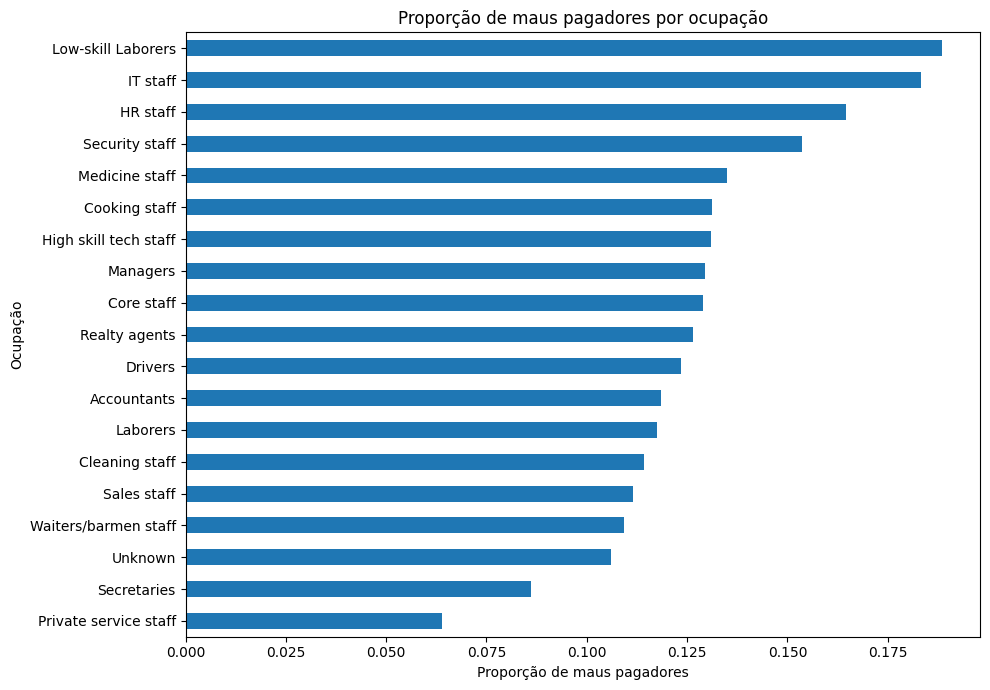

In [ ]:
occupation_bad_rate.sort_values().plot(
    kind='barh',
    figsize=(10, 7)
)

plt.title('Proporção de maus pagadores por ocupação')
plt.xlabel('Proporção de maus pagadores')
plt.ylabel('Ocupação')

plt.tight_layout()
plt.show()

#Conclusão

O projeto teve como objetivo desenvolver modelos de classificação capazes de distinguir bons e maus pagadores a partir das características dos solicitantes. Após o processo de limpeza, transformação das variáveis categóricas e preparação dos dados, foram avaliados diferentes algoritmos de classificação.

Os resultados mostraram que a acurácia, isoladamente, não é suficiente para avaliar os modelos, devido ao desbalanceamento da variável-alvo. Por esse motivo, foram consideradas também métricas como Precision, Recall, F1-score e ROC-AUC.

Entre os modelos avaliados, o Random Forest apresentou o maior ROC-AUC (0,8046) e o maior F1-score (41,38%), indicando uma melhor capacidade de discriminação e equilíbrio entre Precision e Recall dentro dos modelos testados. A Regressão Logística balanceada, por outro lado, apresentou o maior Recall (48,37%), identificando uma parcela maior dos maus pagadores, porém com maior quantidade de falsos positivos.

Na análise das variáveis, AGE_YEARS, EMPLOYMENT_YEARS e AMT_INCOME_TOTAL apresentaram as maiores importâncias no Random Forest. A análise descritiva dessas variáveis, entretanto, não revelou relações simples ou diferenças muito acentuadas entre os grupos de bons e maus pagadores. Dessa forma, os resultados indicam que o comportamento preditivo do modelo pode estar relacionado à combinação entre diferentes características dos solicitantes, e não necessariamente a uma única variável isolada.

Por fim, os resultados devem ser interpretados como relações observadas nos dados e como desempenho preditivo dos modelos, não como evidência de causalidade entre as características dos solicitantes e o comportamento de pagamento.

MELHOR:

Os resultados não indicam a existência de um perfil simples de mau pagador definido por uma única característica. Embora algumas faixas tenham apresentado maiores proporções de maus pagadores na análise descritiva, as diferenças foram relativamente pequenas para idade, renda e tempo de emprego. Ao mesmo tempo, essas variáveis apresentaram alta importância no Random Forest, sugerindo que sua relevância para a classificação pode estar relacionada à combinação com outras características dos solicitantes.

apresentação:

“Nós queríamos descobrir quem são os maus pagadores → encontramos alguns grupos com taxas maiores → mas percebemos que não existe um perfil simples → por isso usamos modelos capazes de combinar várias características → o Random Forest teve o melhor desempenho global entre os modelos testados.”